<a href="https://colab.research.google.com/github/vnandigam/CHM_lidar_lidR/blob/main/OF4D_Meta_WRI_CHM_API_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenForest4D META/WRI Global Canopy Height Maps v2 API Example

This notebook walks through querying the OpenForest4D API to retrieve and visualize a clipped Meta/WRI Version 2 Canopy Height Model (CHM) for a user-defined area of interest (AOI). Data are downloaded as a GeoTIFF in EPSG:3857 (Web Mercator), then visualized, with a canopy height histogram generated for exploratory analysis.

This dataset was produced using machine learning models applied to high-resolution Vantor satellite imagery, leveraging a DINOv3 backbone (March 2026 release). More information is available at [ai.meta.com](https://ai.meta.com/blog/world-resources-institute-dino-canopy-height-maps-v2/).

Author: Viswanath Nandigam, UC San Diego.

| | |
|-------|------|
| **Data product** | Meta / WRI Canopy Height Maps v2 |
| **API endpoint** | `POST https://of4d-compute.sdsc.edu/API/v1/meta_WRI_dl_chm_v2` |
| **Auth** | Bearer token (`apikey` in body + `Authorization` header) |
| **Output CRS** | EPSG:3857 (Web Mercator) |
| **AOI limit** | 1,000 km2 |
| **Area of interest** | User provided AOI/Spatial bounding box |


---
## 1. Install and Import Dependencies


In [1]:
# Install packages not already present in Colab
!pip install -q rasterio matplotlib numpy requests matplotlib-scalebar

In [2]:
import os
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar
import rasterio
from rasterio.enums import Resampling
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded.')

All libraries loaded.


---
## 2. Set Your API Key

A free API key is required to access the OpenForest4D CHM v2 endpoint. You can request a key through the [OpenForest4D portal](https://openforest4d.org).

The API requires the key to be included in two locations (both required by the API spec):

- As the `apikey` field in the JSON request body
- As a **Bearer token** in the `Authorization` HTTP header

In [6]:
# Option A: enter interactively so the key is not stored in the notebook
import getpass
API_KEY = getpass.getpass('Enter your OpenForest4D API key: ')

# Option B: load from Colab Secrets (recommended for shared notebooks)
# In Colab: click the key icon in the left sidebar, add a secret named OF4D_API_KEY
# Then uncomment the two lines below and comment out the lines in Option A above:
# from google.colab import userdata
# API_KEY = userdata.get('OF4D_API_KEY')

# Option C: paste your key directly (only for personal use)
# WARNING: If you share or commit this notebook, your key will be exposed.
# Uncomment the line below and comment out the lines in Option A above:
# API_KEY = 'YOUR_OPENFOREST4D_API_KEY_HERE'

if not API_KEY or API_KEY == 'YOUR_OPENFOREST4D_API_KEY_HERE':
    raise ValueError(
        'No API key set.\n'
    )
print('API key loaded.')

Enter your OpenForest4D API key: ··········
API key loaded.


---
## 3. Define the user spatial area of interest / Bounding Box
For this example we use an AOI centred on the **Zigzag / Sandy River Gorge** area of Mount Hood National Forest.  
> **Tip:** Adjust `BBOX` to any other spatial area ensuring selection area is within the 1,000 km2 API limit per call.

| Corner | Longitude | Latitude |
|--------|-----------|----------|
| South-West | -121.980 | 45.210 |
| North-East | -121.780 | 45.410 |


In [7]:
# Input CRS: WGS-84 / EPSG:4326  (API accepts lon/lat and returns EPSG:3857)
BBOX = {
    'min_lon': -121.980,
    'min_lat':   45.210,
    'max_lon': -121.780,
    'max_lat':   45.410,
}

# Rough area check
mid_lat     = (BBOX['min_lat'] + BBOX['max_lat']) / 2
lon_span_km = (BBOX['max_lon'] - BBOX['min_lon']) * 111.320 * np.cos(np.radians(mid_lat))
lat_span_km = (BBOX['max_lat'] - BBOX['min_lat']) * 110.574
area_km2    = lon_span_km * lat_span_km

print(f'AOI dimensions  : {lon_span_km:.1f} km (E-W) x {lat_span_km:.1f} km (N-S)')
print(f'Approximate area: {area_km2:.0f} km2  (API limit: 1,000 km2)')
assert area_km2 <= 1000, f'AOI too large ({area_km2:.0f} km2). Reduce the bounding box.'
print(f'Bounding box    : {BBOX}')


AOI dimensions  : 15.7 km (E-W) x 22.1 km (N-S)
Approximate area: 346 km2  (API limit: 1,000 km2)
Bounding box    : {'min_lon': -121.98, 'min_lat': 45.21, 'max_lon': -121.78, 'max_lat': 45.41}


---
## 4. Query the OpenForest4D Meta/WRI CHM API

**Method:** `POST`  
**URL:** `https://of4d-compute.sdsc.edu/API/v1/meta_WRI_dl_chm_v2`  
**Auth:** `Authorization: Bearer <apikey>` header (HTTPBearer scheme)

**JSON request body (`MetaWriChmV2Request`):**

| Field | Type | Description |
|-------|------|-------------|
| `apikey` | string | Your OpenForest4D API key |
| `min_lon` | float [-180, 180] | Western boundary (EPSG:4326) |
| `min_lat` | float [-90, 90] | Southern boundary (EPSG:4326) |
| `max_lon` | float [-180, 180] | Eastern boundary (EPSG:4326) |
| `max_lat` | float [-90, 90] | Northern boundary (EPSG:4326) |
| `geojson` | object (optional) | GeoJSON polygon - used only if bbox fields are omitted |

**Returns:** GeoTIFF binary stream clipped to AOI, projected in **EPSG:3857** (Web Mercator).


In [9]:
API_BASE    = 'https://of4d-compute.sdsc.edu/API'
ENDPOINT    = '/v1/meta_WRI_dl_chm_v2'
OUTPUT_PATH = 'chm.tif'

# Request body - MetaWriChmV2Request schema
payload = {
    'apikey':  API_KEY,
    'min_lon': BBOX['min_lon'],
    'min_lat': BBOX['min_lat'],
    'max_lon': BBOX['max_lon'],
    'max_lat': BBOX['max_lat'],
    # 'geojson': None   # optional GeoJSON polygon; ignored when bbox is supplied
}

# Auth: Bearer token in Authorization header (HTTPBearer scheme)
headers = {
    'Authorization': f'Bearer {API_KEY}',
    'Content-Type':  'application/json',
    'Accept':        'application/octet-stream',
}

print('Querying OpenForest4D META/WRI CHM v2 API ...')
print(f'  URL    : {API_BASE}{ENDPOINT}')
print(f'  Method : POST (JSON body)')
print(f'  Auth   : Bearer ***{API_KEY[-4:]}')
print()

response = requests.post(
    f'{API_BASE}{ENDPOINT}',
    json=payload,
    headers=headers,
    timeout=300,   # large GeoTIFF may take a while
    stream=True,   # enables chunked download via iter_content below
)

# Error handling
if response.status_code == 401:
    raise PermissionError('HTTP 401 Unauthorized - check your API key.')
elif response.status_code == 422:
    raise ValueError(f'HTTP 422 Validation Error:\n{response.text}')
elif response.status_code != 200:
    raise RuntimeError(f'HTTP {response.status_code}\n{response.text[:500]}')

content_type = response.headers.get('Content-Type', '')
print(f'Response OK  |  Status: {response.status_code}  |  Content-Type: {content_type}')

# Stream GeoTIFF to disk
total_bytes = 0
with open(OUTPUT_PATH, 'wb') as f:
    for chunk in response.iter_content(chunk_size=256 * 1024):
        if chunk:
            f.write(chunk)
            total_bytes += len(chunk)

print(f'Saved to: {OUTPUT_PATH}  ({total_bytes / 1_048_576:.1f} MB)')


Querying OpenForest4D API ...
  URL    : https://of4d-compute.sdsc.edu/API/v1/meta_WRI_dl_chm_v2
  Method : POST (JSON body)
  Auth   : Bearer ***0d41

Response OK  |  Status: 200  |  Content-Type: image/tiff
Saved to: chm.tif  (145.7 MB)


---
## 5. Inspect the GeoTIFF Metadata

> The API returns the raster in **EPSG:3857** (Web Mercator). Coordinates are in metres, not degrees.


In [10]:
with rasterio.open(OUTPUT_PATH) as src:
    meta   = src.meta
    bounds = src.bounds
    crs    = src.crs
    res    = src.res          # (x_res, y_res) in metres (EPSG:3857)
    nodata = src.nodata
    chm    = src.read(1).astype('float32')

print('-' * 55)
print(f'CRS           : {crs}')
print(f'Shape         : {chm.shape[0]} rows x {chm.shape[1]} cols')
print(f'Resolution    : {res[0]:.4f} x {res[1]:.4f} m/pixel')
print(f'Bounds (m)    : {bounds}')
print(f'NoData value  : {nodata}')
print(f'Data type     : {meta["dtype"]}')
print('-' * 55)

# Mask nodata and negative/implausible values
if nodata is not None:
    chm = np.where(chm == nodata, np.nan, chm)
chm = np.where(chm < 0, np.nan, chm)

valid = chm[~np.isnan(chm)]
print(f'Valid pixels  : {valid.size:,}')
print(f'Height range  : {valid.min():.1f} - {valid.max():.1f} m')
print(f'Mean height   : {valid.mean():.1f} m')
print(f'Median height : {np.median(valid):.1f} m')


-------------------------------------------------------
CRS           : EPSG:3857
Shape         : 26508 rows x 18643 cols
Resolution    : 1.1943 x 1.1943 m/pixel
Bounds (m)    : BoundingBox(left=-13578752.630334059, bottom=5654641.757880831, right=-13556486.7628603, top=5686301.0195336975)
NoData value  : 255.0
Data type     : uint8
-------------------------------------------------------
Valid pixels  : 494,188,644
Height range  : 0.0 - 67.0 m
Mean height   : 18.2 m
Median height : 18.0 m


---
## 6. Visualise the Canopy Height Model


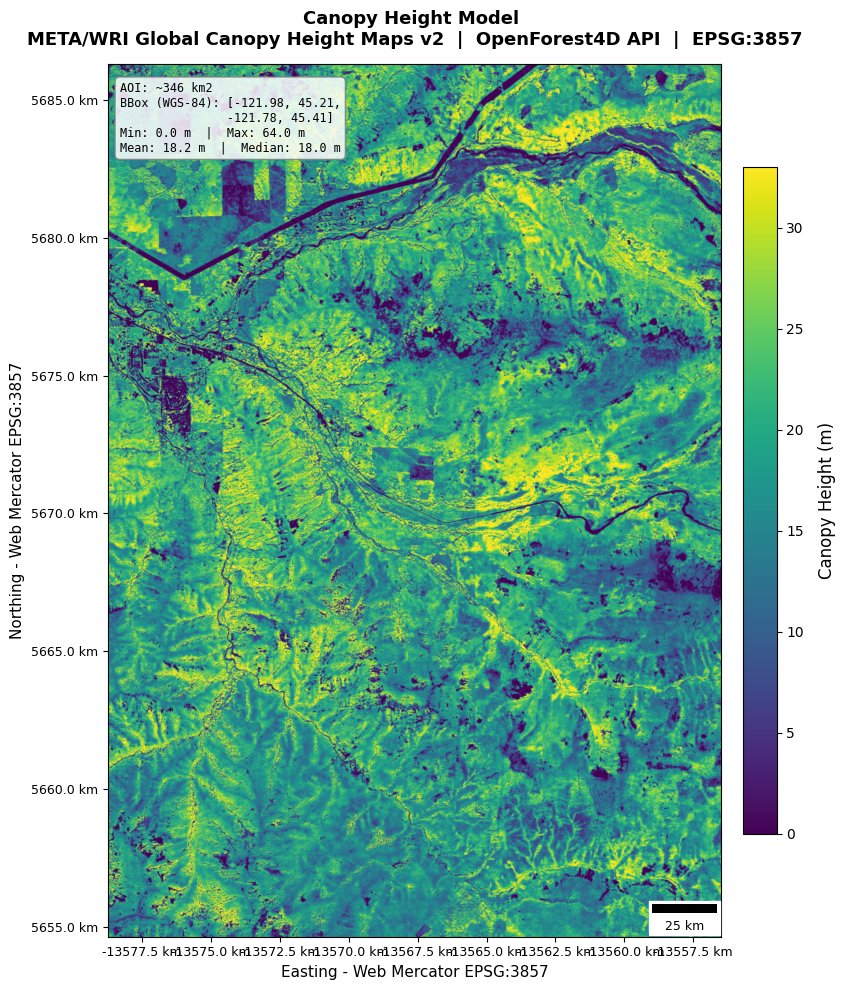

Map saved: chm_map.png


In [11]:
# Set the color map for visualization

forest_cmap = plt.get_cmap('viridis')
# forest_cmap = plt.get_cmap('plasma')

# Optional - Set a custom forest-themed colormap
#forest_colors = [
#    (0.95, 0.95, 0.88),   # 0 m   - bare / very short  (cream)
#    (0.72, 0.88, 0.60),   # ~5 m  - shrubs             (light green)
#    (0.25, 0.65, 0.25),   # ~15 m - young forest       (medium green)
#    (0.05, 0.42, 0.10),   # ~30 m - mature forest      (dark green)
#    (0.00, 0.22, 0.05),   # ~50 m - tall old-growth    (very dark green)
#    (0.60, 0.45, 0.20),   # >60 m - emergent / edge    (brown-gold)
#]
#forest_cmap = mcolors.LinearSegmentedColormap.from_list('forest', forest_colors, N=256)


# 2. Target resolution for visualization (e.g., max 3000 pixels on the long edge)
MAX_VIZ_DIM = 3000

# 3. Open file and read downsampled grid directly (Safe for Google Colab default memory).

# Option 1 -  bilinear resampling - smooth output, faster. Good for overview maps.

with rasterio.open(OUTPUT_PATH) as src:
    b = src.bounds
    extent_m = [b.left, b.right, b.bottom, b.top]

    # Calculate downsampled shape maintaining aspect ratio
    orig_height, orig_width = src.height, src.width
    scale = min(MAX_VIZ_DIM / orig_height, MAX_VIZ_DIM / orig_width, 1.0)

    out_height = int(orig_height * scale)
    out_width = int(orig_width * scale)
    out_shape = (src.count, out_height, out_width)

    # Dynamically compute scalebar pixel size based on the new grid dimensions
    # scalebar needs the geographic distance spanning one pixel in the downsampled array
    pixel_size_m = (b.right - b.left) / out_width

    # Read downsampled data directly into memory
    # Resampling.bilinear or Resampling.nearest can be specified if needed
    chm_downsampled = src.read(1, out_shape=(out_height, out_width), resampling=rasterio.enums.Resampling.bilinear)

# Option 2 - average resampling - sharper canopy edges, better for analysis. Uncomment below and comment out Option 1 to use.
# Highly detailed but perfectly safe for Colab memory

#with rasterio.open(OUTPUT_PATH) as src:
#    b = src.bounds
#    extent_m = [b.left, b.right, b.bottom, b.top]
#
#    orig_height, orig_width = src.height, src.width
#    scale = min(MAX_VIZ_DIM / orig_height, MAX_VIZ_DIM / orig_width, 1.0)
#
#    out_height = int(orig_height * scale)
#    out_width = int(orig_width * scale)
#
#    pixel_size_m = (b.right - b.left) / out_width
#
#    # Use 'average' or 'nearest' to keep edge sharpness crisp
#    chm_downsampled = src.read(
#        1,
#        out_shape=(out_height, out_width),
#        resampling=Resampling.average # Keeps canopy structures sharp
#    )


# 4. Calculate stats on the downsampled data to save RAM
valid_mask = ~np.isnan(chm_downsampled)
valid_data = chm_downsampled[valid_mask]

vmin = 0
vmax = float(np.percentile(valid_data, 98)) if len(valid_data) > 0 else 50

# 5. Plotting
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    chm_downsampled,
    cmap=forest_cmap,
    vmin=vmin,
    vmax=vmax,
    extent=extent_m,
    interpolation='bilinear',
    origin='upper',
    aspect='equal',
)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, shrink=0.85)
cbar.set_label('Canopy Height (m)', fontsize=12, labelpad=10)
cbar.ax.tick_params(labelsize=10)

# Axes formatting (metres to km)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.1f} km'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.1f} km'))
ax.set_xlabel('Easting - Web Mercator EPSG:3857', fontsize=11)
ax.set_ylabel('Northing - Web Mercator EPSG:3857', fontsize=11)
ax.tick_params(labelsize=9)

ax.set_title(
    'Canopy Height Model \n'
    'META/WRI Global Canopy Height Maps v2  |  OpenForest4D API  |  EPSG:3857',
    fontsize=13, fontweight='bold', pad=14,
)

# Stats box (generated using downsampled data arrays to avoid holding full original arrays)
stats_txt = (
    f'AOI: ~{area_km2:.0f} km2\n'
    f'BBox (WGS-84): [{BBOX["min_lon"]}, {BBOX["min_lat"]},\n'
    f'               {BBOX["max_lon"]}, {BBOX["max_lat"]}]\n'
    f'Min: {valid_data.min():.1f} m  |  Max: {valid_data.max():.1f} m\n'
    f'Mean: {valid_data.mean():.1f} m  |  Median: {np.median(valid_data):.1f} m'
)
ax.text(
    0.02, 0.98, stats_txt,
    transform=ax.transAxes, fontsize=8.5,
    verticalalignment='top', fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.85, edgecolor='grey'),
)

# Scale bar
try:
    scalebar = ScaleBar(
        pixel_size_m, 'm',
        location='lower right',
        font_properties={'size': 9},
        scale_loc='bottom',
    )
    ax.add_artist(scalebar)
except Exception:
    pass # scalebar is optional; skip silently if matplotlib-scalebar is unavailable

plt.tight_layout()
plt.savefig('chm_map.png', dpi=200, bbox_inches='tight')
plt.show()
print('Map saved: chm_map.png')

---
## 7. Canopy Height Distribution - Histogram


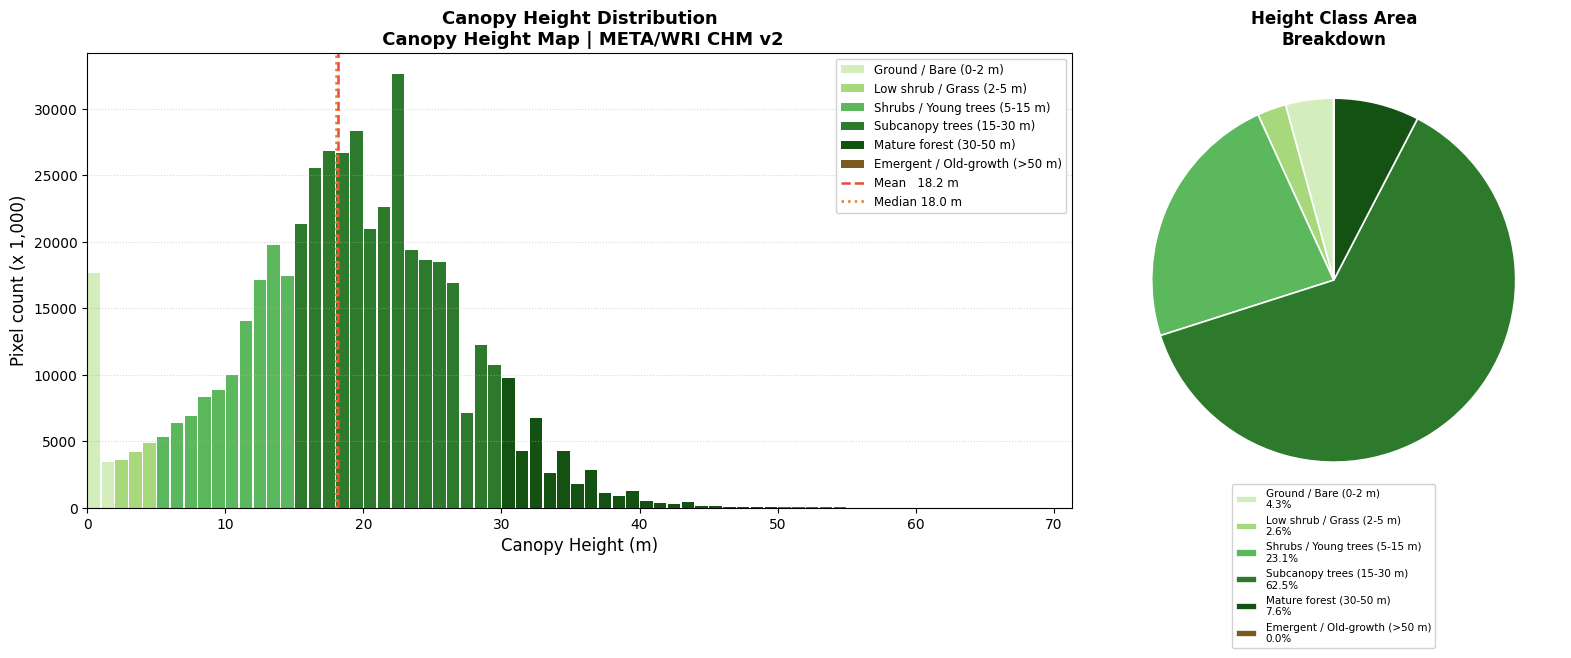

Histogram saved: chm_histogram.png


In [12]:
# Requires `valid` and `chm` from Section 5

HEIGHT_CLASSES = [
    (0,    2,  '#d4edbc', 'Ground / Bare (0-2 m)'),
    (2,    5,  '#a8d87c', 'Low shrub / Grass (2-5 m)'),
    (5,   15,  '#5cb85c', 'Shrubs / Young trees (5-15 m)'),
    (15,  30,  '#2d7a2d', 'Subcanopy trees (15-30 m)'),
    (30,  50,  '#145214', 'Mature forest (30-50 m)'),
    (50, 999,  '#7a5c1e', 'Emergent / Old-growth (>50 m)'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 1]})

# Left panel: 1 m bin histogram
ax1 = axes[0]
bins        = np.arange(0, np.nanmax(chm) + 2, 1)
counts, edges = np.histogram(valid, bins=bins)
bin_centres = (edges[:-1] + edges[1:]) / 2

bar_colors = []
for h in bin_centres:
    c = '#aaaaaa'
    for lo, hi, col, _ in HEIGHT_CLASSES:
        if lo <= h < hi:
            c = col
            break
    bar_colors.append(c)

ax1.bar(bin_centres, counts / 1_000, color=bar_colors, width=0.9, linewidth=0)

mean_h   = valid.mean()
median_h = np.median(valid)
ax1.axvline(mean_h,   color='#e74c3c', lw=1.8, ls='--', label=f'Mean   {mean_h:.1f} m')
ax1.axvline(median_h, color='#e67e22', lw=1.8, ls=':',  label=f'Median {median_h:.1f} m')

ax1.set_xlabel('Canopy Height (m)', fontsize=12)
ax1.set_ylabel('Pixel count (x 1,000)', fontsize=12)
ax1.set_title(
    'Canopy Height Distribution\n Canopy Height Map | META/WRI CHM v2',
    fontsize=13, fontweight='bold',
)
ax1.grid(axis='y', linestyle=':', alpha=0.5)
ax1.set_xlim(left=0)

legend_patches = [Patch(facecolor=col, label=lbl) for _, _, col, lbl in HEIGHT_CLASSES]
ax1.legend(
    handles=legend_patches + [
        plt.Line2D([0], [0], color='#e74c3c', lw=1.8, ls='--', label=f'Mean   {mean_h:.1f} m'),
        plt.Line2D([0], [0], color='#e67e22', lw=1.8, ls=':',  label=f'Median {median_h:.1f} m'),
    ],
    fontsize=8.5, loc='upper right', framealpha=0.9,
)

# Right panel: height-class pie chart
ax2 = axes[1]
labels, areas, colors = [], [], []
total_pixels = valid.size

for lo, hi, col, lbl in HEIGHT_CLASSES:
    n   = np.sum((valid >= lo) & (valid < hi))
    pct = 100 * n / total_pixels if total_pixels else 0
    labels.append(f'{lbl}\n{pct:.1f}%')
    areas.append(n)
    colors.append(col)

wedges, _ = ax2.pie(
    areas,
    labels=None,
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.2),
)
ax2.legend(
    wedges, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.32),
    fontsize=7.5, framealpha=0.9, ncol=1,
)
ax2.set_title('Height Class Area\nBreakdown', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('chm_histogram.png', dpi=200, bbox_inches='tight')
plt.show()
print('Histogram saved: chm_histogram.png')


---
## 8. Percentile Summary Table


In [13]:
percentiles = [5, 10, 25, 50, 75, 90, 95, 99]
pct_values  = np.percentile(valid, percentiles)

print('=' * 42)
print('  CHM Height Percentiles')
print('-' * 42)
print(f'  {"Percentile":>12}   {"Height (m)":>12}')
print('-' * 42)
for p, v in zip(percentiles, pct_values):
    print(f'  {f"P{p}":>12}   {v:>10.1f} m')
print('-' * 42)
print(f'  {"Mean":>12}   {valid.mean():>10.1f} m')
print(f'  {"Std Dev":>12}   {valid.std():>10.1f} m')
print(f'  {"Min":>12}   {valid.min():>10.1f} m')
print(f'  {"Max":>12}   {valid.max():>10.1f} m')
print('=' * 42)

print('\n  Forest cover by height threshold:')
for thr in [2, 5, 10, 15, 20, 30]:
    pct = 100 * np.sum(valid >= thr) / valid.size
    print(f'  Pixels >= {thr:>3} m : {pct:>5.1f}%')


  CHM Height Percentiles
------------------------------------------
    Percentile     Height (m)
------------------------------------------
            P5          3.0 m
           P10          7.0 m
           P25         13.0 m
           P50         18.0 m
           P75         23.0 m
           P90         28.0 m
           P95         31.0 m
           P99         37.0 m
------------------------------------------
          Mean         18.2 m
       Std Dev          8.2 m
           Min          0.0 m
           Max         67.0 m

  Forest cover by height threshold:
  Pixels >=   2 m :  95.7%
  Pixels >=   5 m :  93.2%
  Pixels >=  10 m :  85.9%
  Pixels >=  15 m :  70.1%
  Pixels >=  20 m :  44.0%
  Pixels >=  30 m :   7.6%


---
## 9. Download Outputs (Colab only)


In [14]:
try:
    from google.colab import files
    for path in [OUTPUT_PATH, 'chm_map.png', 'chm_histogram.png']:
        files.download(path)
    print('Downloads triggered.')
except ImportError:
    print('Not running in Colab - files are in the current directory:')
    for path in [OUTPUT_PATH, 'chm_map.png', 'chm_histogram.png']:
        if os.path.exists(path):
            print(f'  {path}  ({os.path.getsize(path) / 1024:.0f} KB)')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads triggered.


---
### NSF funding acknowledgement

OpenForest4D is funded by National Science Foundation (NSF) awards [2409885](https://www.nsf.gov/awardsearch/showAward?AWD_ID=2409885), 2409886 & 2409887.


### Data citation

Version 2 High Resolution Canopy Height Maps by WRI and Meta was accessed on `DATE` from https://registry.opendata.aws/dataforgood-fb-forestsv2. Meta and World Resources Institute (WRI) - 2026. Version 2 High Resolution Canopy Height Maps (CHMv2). Source imagery for CHM © 2016 Vantor. Accessed `DAY` `MONTH` `YEAR` via NSF OpenForest4D API.


